## WorldView Scene-Combination Benchmark, Full Scenes: SpaceNet UCSD

The [scene-combination benchmark](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_benchmark.html) scored 17 DEMs over a 3 × 3 km crop (Mount Soledad, "crop A") of five multi-date WorldView-3 scenes from the CORE3D UCSD set. Its second-site conclusions disagreed with Atlanta: no convergence-angle curve, an 8° pair as the best single pair, worse pairs whenever the 2014-11-09 nadir scene was in them, and no flow distinguishable from another. But the crop held only 502 shared ICESat-2 points on 19 beam tracks, too few to separate 12 of the 16 other DEMs from the best.

The [Atlanta full-strip notebook](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_atlanta_full_benchmark.html) repeated the Atlanta half on the full strips (uw-cryo/asp_plot#207). This notebook does the same for UCSD, with a selective set of runs:
- Do the crop's UCSD conclusions hold over about 17 times the ground and ICESat-2 sample?
- Does mapprojection onto Copernicus GLO-30 help over steep terrain? Over flat Atlanta, raw stereo beat it on wide pairs.
- Do the full-scene DEMs, clipped to crop A, reproduce the crop's numbers?

### Key takeaways

Eighteen full-scene DEMs, scored on 14,237 ICESat-2 points of stable terrain valid in all of them, on 100 beam tracks over the 182 km² common area (the crop had 502 points on 19 tracks):

1. **The crop's UCSD conclusions mostly came from its small sample.** Over the full scenes the bootstrap separates all but one DEM from the best, and two of the crop's findings reverse:
    - The 8° pair, the crop's best single pair, is now the worst (1.32 m).
    - The 2014-11-09 nadir scene does not degrade its pairs: they average 0.02 m *better* than the pairs without it.
2. **There is a convergence curve at the multi-date site too, but it flattens early.** NMAD falls from 1.32 m at 8° and 1.20 m at 9° to 1.10–1.18 m at 15–17°. From 15° to 34° it stays at 1.06–1.21 m, and which two dates are paired matters as much as the angle: the 19.5° pair n15-n08 scores 1.21 m, the 25° pair n24-n16 1.06 m.
3. **At a multi-date site, average every pair; don't drop the narrow ones.** The plain `dem_mosaic` average of all ten pairs is the best DEM (1.03 m, first in 97 % of bootstrap replicates). It ties only with the best single pair (1.06 m).
    - Dropping the two pairs below 15° makes the blend worse (1.13 m), the opposite of Atlanta. There the same-pass narrow pairs were biased, and dropping them took the blend from 1.08 to 0.86 m.
    - Here each pair carries different dates, so more pairs average out more independent matching errors.
    - The median blend is close (1.07 m).
    - The joint five-scene multi-view run is 0.06 m behind the average (1.09 m, separable). The ASP manual discourages multi-view stereo for multi-date stacks.
4. **Mapprojection onto COP30 neither helps nor hurts overall at UCSD,** within 0.02 m on all three pairs. That is unlike flat Atlanta, where raw stereo won by 0.11–0.15 m on wide pairs. Mapprojection's gains are where expected, but small:
    - It covers up to 5 % more of the area (most on the widest pair).
    - It is 0.10–0.16 m better on 10–20° slopes for the two wide pairs.
    - It is 0.03–0.17 m better on grass, shrub and bare ground.
    - It is no better on built-up ground or on the steepest slopes (> 20°, about 450 points).
    The big win expected from steep topography did not show up in the altimetry. Most stable ICESat-2 points are on gentle ground, and the steep canyon walls are mostly wooded.
5. **On crop A, the full-scene DEMs reproduce the crop when they keep their full-scene alignment:** within −0.39 to +0.24 m, most within ±0.12 m. Refitting `pc_align` on the 9 km² clip, as the crop did, is unstable on this steep ground: one DEM's NMAD goes from 1.33 to 1.73 m. Crop-sized altimetry samples should not be used to fit an alignment over steep terrain.
6. **Trees matter less here than at Atlanta.** Scoring all land points instead of stable terrain adds 0.04–0.16 m to every NMAD and barely changes the ranking. At Atlanta it roughly doubled every NMAD.

**Scope.** One multi-date, steep, urban site, one ICESat-2 sample, and 13 stereo runs: the 10 pairs and one multi-view run mapprojected, 3 pairs raw. The UCSD round used about 265 SBU on the NASA NAS supercomputer.

---

## Testbed

The same five winter 2014-15 WorldView-3 scenes as the cropped study, from the IARPA CORE3D UCSD set (`s3://spacenet-dataset/Hosted-Datasets/CORE3D-Public-Data/Satellite-Images/UCSD/WV3/PAN/`). Each scene is one separate collect, so every pair is multi-date, weeks to months apart. Each is a single JPEG2000 NITF, decoded once to GeoTIFF with ASP's GDAL:

```bash
GDAL_DRIVER_PATH=$ASP_ROOT/lib/gdalplugins gdal_translate -co TILED=YES -co COMPRESS=DEFLATE -co BIGTIFF=YES \
    -co PROFILE=BASELINE --config GDAL_PAM_ENABLED NO <scene>.NTF <CATID>.tif
```

`PROFILE=BASELINE` with PAM off writes no georeferencing. The NITF corner coordinates otherwise give the GeoTIFF a lat/lon geotransform, which ASP and asp_plot read as "already map-projected". Removing that geotransform with `gdal_edit.py -unsetgt`, as the cropped study did, left an all-zero geotransform with ASP 3.7.0's GDAL, and `bundle_adjust` then failed at once with *Matrix is singular in inverse()*.

Processing ran on the NASA NAS (Pleiades) supercomputer with ASP 3.7.0. The cropped study ran on a laptop with ASP 3.8.0-alpha.

In [1]:
import os
import re

import numpy as np
import pandas as pd

# Set the base directory for your processing
directory = "/nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/"
directory = os.path.expanduser(directory)
scenes_dir = os.path.dirname(os.path.dirname(directory)) + "/"
ref_dir = "/nobackup/bpurint1/data/ucsd/ref/"

# The cropped study's short names: off-nadir angle, and the 2014-11-09 near-nadir scene
SCENES = {
    "104001000496A100": "nadir",
    "10400100047BBB00": "n15",
    "10400100057DD500": "n24",
    "10400100071D8800": "n16",
    "1040010007A93700": "n08",
}


def xml_value(xml, tag):
    m = re.search(f"<{tag}>([^<]+)</{tag}>", open(xml).read())
    return m.group(1) if m else None


rows = []
for catid, name in SCENES.items():
    xml = f"{scenes_dir}{catid}.xml"
    rows.append(
        {
            "name": name,
            "catid": catid,
            "date": xml_value(xml, "FIRSTLINETIME")[:10],
            "lines": int(xml_value(xml, "NUMROWS")),
            "samples": int(xml_value(xml, "NUMCOLUMNS")),
            "off-nadir (deg)": float(xml_value(xml, "MEANOFFNADIRVIEWANGLE")),
            "sat az (deg)": float(xml_value(xml, "MEANSATAZ")),
            "sun el (deg)": float(xml_value(xml, "MEANSUNEL")),
            "GSD (m)": float(xml_value(xml, "MEANPRODUCTGSD")),
        }
    )
scenes = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
scenes

,name,catid,date,lines,samples,off-nadir (deg),sat az (deg),sun el (deg),GSD (m)
0,nadir,104001000496A100,2014-11-09,47104,43008,1.1,184.8,38.1,0.308
1,n15,10400100047BBB00,2014-11-28,44032,43008,14.7,172.6,33.5,0.327
2,n24,10400100057DD500,2014-12-23,43008,43008,24.1,132.4,30.3,0.362
3,n16,10400100071D8800,2015-01-24,45056,43008,16.3,199.2,34.3,0.332
4,n08,1040010007A93700,2015-02-12,46080,43008,8.4,268.3,39.6,0.315


### Footprints

The five footprints share 182 km², part of it ocean off La Jolla. Crop A is a small part of that common area. The ICESat-2 ATL06-SR sample was requested once over the union of the footprints, with ESA WorldCover sampled at every point, and is replayed for every DEM.

esa_worldcover.value,built,water,tree,grass,shrub,bare,wetland,crop
ICESat-2 points in the common area,15527,7856,5452,3740,1962,501,206,26


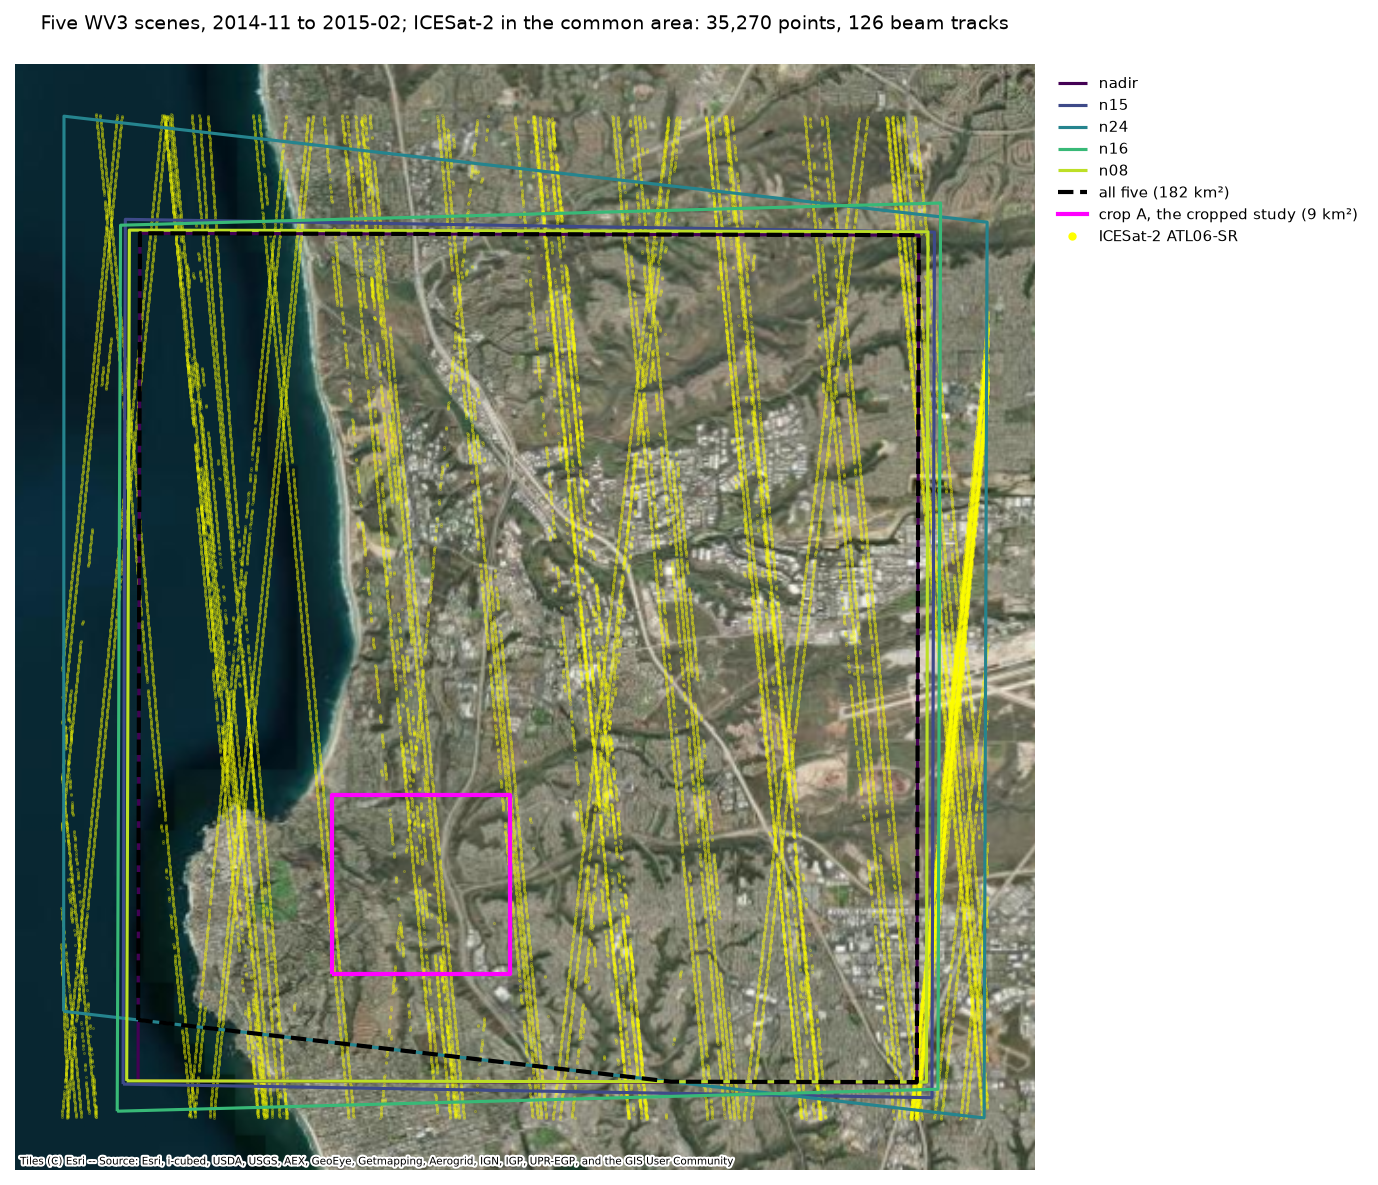

In [2]:
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, box


def footprint(xml):
    s = open(xml).read()
    s = s[s.find("<BAND_P>"):s.find("</BAND_P>")]
    corner = lambda c: (float(re.search(f"<{c}LON>([^<]+)<", s).group(1)), float(re.search(f"<{c}LAT>([^<]+)<", s).group(1)))
    return Polygon([corner(c) for c in ("UL", "UR", "LR", "LL")])


utm = "EPSG:32611"
fp = gpd.GeoDataFrame(
    {"name": list(SCENES.values()), "geometry": [footprint(f"{scenes_dir}{c}.xml") for c in SCENES]},
    crs="EPSG:4326",
).to_crs(utm)
common = gpd.GeoSeries([fp.geometry.intersection_all()], crs=utm)
CROP_A = (476000, 3632000, 479000, 3635000)
crop = gpd.GeoSeries([box(*CROP_A)], crs=utm)

atl = gpd.read_parquet(f"{directory}atl06sr_all.parquet").to_crs(utm)
atl_c = atl[atl.within(common.iloc[0])]
WC = {10: "tree", 20: "shrub", 30: "grass", 40: "crop", 50: "built", 60: "bare", 80: "water", 90: "wetland"}

fig, ax = plt.subplots(figsize=(9, 8), dpi=150)
for (_, r), color in zip(fp.iterrows(), plt.cm.viridis(np.linspace(0, 0.9, len(fp)))):
    gpd.GeoSeries([r.geometry], crs=utm).boundary.plot(ax=ax, color=color, lw=1.5, label=r["name"], zorder=3)
common.boundary.plot(ax=ax, color="k", lw=2, ls="--", zorder=4)
crop.boundary.plot(ax=ax, color="magenta", lw=2, zorder=4)
atl.plot(ax=ax, color="yellow", markersize=0.1, alpha=0.4, zorder=2)
ax.plot([], [], "k--", lw=2, label=f"all five ({common.area.iloc[0] / 1e6:.0f} km²)")
ax.plot([], [], color="magenta", lw=2, label=f"crop A, the cropped study ({crop.area.iloc[0] / 1e6:.0f} km²)")
ax.plot([], [], ".", color="yellow", label="ICESat-2 ATL06-SR")
ctx.add_basemap(ax, crs=utm, source=ctx.providers.Esri.WorldImagery, attribution_size=5)
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
n_tracks = atl_c.groupby(["rgt", "cycle", "spot"]).ngroups
ax.set_title(f"Five WV3 scenes, 2014-11 to 2015-02; ICESat-2 in the common area: {len(atl_c):,} points, {n_tracks} beam tracks", fontsize=9)
ax.set_axis_off()
fig.tight_layout()

pd.Series(atl_c["esa_worldcover.value"].map(WC).value_counts(), name="ICESat-2 points in the common area").to_frame().T

---

## Bundle adjustment

One `bundle_adjust` of the five full scenes, with the cropped study's settings. The cropped study also adjusted the full scenes.

```bash
bundle_adjust -t dg --threads 28 \
    --ip-per-image 10000 --tri-weight 0.1 --tri-robust-threshold 0.1 --camera-weight 0 \
    <nadir n15 n24 n16 n08>.tif <...>.xml -o ba/run
```

It took 69 minutes on one 28-core Broadwell node. The median reprojection error after adjustment is 0.22–0.24 px for every camera. The convergence angles match the cropped study's to 0.1°. The oblique 2014-12-23 scene (n24) has the fewest matches, as in the crop: matching it to a scene imaged weeks apart from 24° is the hardest step.

In [3]:
conv = pd.read_csv(f"{directory}ba/run-convergence_angles.txt", sep=r"\s+", comment="#",
                   names=["left", "right", "p25", "p50", "p75", "num_matches"])
for c in ("left", "right"):
    conv[c] = conv[c].str.replace(".tif", "", regex=False).map(SCENES)
conv["pair"] = conv["left"] + "-" + conv["right"]
# The cropped study's convergence (its BA of the same full scenes)
crop_p50 = {"n15-n16": 8.0, "nadir-n08": 9.2, "nadir-n15": 14.9, "nadir-n16": 16.9, "n16-n08": 17.1,
            "n15-n24": 17.5, "n15-n08": 19.4, "n24-n16": 25.3, "nadir-n24": 25.9, "n24-n08": 33.9}
conv["crop p50"] = conv["pair"].map(crop_p50)
conv = conv.sort_values("p50").reset_index(drop=True)
conv_of = dict(zip(conv["pair"], conv["p50"]))
conv[["pair", "p50", "p25", "p75", "crop p50", "num_matches"]].rename(columns={"p50": "convergence (deg)"}).round(2)

,pair,convergence (deg),p25,p75,crop p50,num_matches
0,n15-n16,7.99,7.99,7.99,8.0,8016
1,nadir-n08,9.16,9.15,9.16,9.2,6498
2,nadir-n15,15.05,15.03,15.08,14.9,5804
3,nadir-n16,16.83,16.80,16.87,16.9,4652
4,n16-n08,17.11,17.08,17.14,17.1,4546
5,n15-n24,17.53,17.50,17.56,17.5,2535
6,n15-n08,19.51,19.50,19.53,19.4,3265
7,n24-n16,25.34,25.31,25.37,25.3,1488
8,nadir-n24,25.97,25.95,25.99,25.9,1220
9,n24-n08,33.97,33.94,33.98,33.9,720


---

## Processing

A selective set: 13 stereo runs, against 21 at Atlanta, chosen to answer the questions above.

| Run | Mode | Tests |
|---|---|---|
| all ten pairs | mapprojected | the convergence curve and the nadir-scene effect; the blends need all ten |
| MVS 5 ref n08 | mapprojected | joint multi-view against the blends and the best pair (n08 was the crop's best reference; at Atlanta the reference barely mattered over the strip) |
| `dem_mosaic` of all ten and of the eight > 15°, default and `--median` | mapprojected | the pairwise flow, and whether excluding pairs below 15° costs the best pair |
| pairs n15-n16 (8°), n24-n16 (25°), n24-n08 (34°) | raw | raw against mapprojected over steep terrain, across the angle range |

**Settings.** As in the cropped study: `parallel_stereo --stereo-algorithm asp_mgm --subpixel-mode 9 --bundle-adjust-prefix ba/run`, then `point2dem --tr 1.2 --t_srs EPSG:32611 --errorimage`. The two modes differ as follows:
- **raw:** `--alignment-method affineepipolar` on the full scenes.
- **mapprojected:** every scene is mapprojected once onto COP30 at 0.35 m (UTM 11N, ellipsoid heights, BA'd cameras), then stereo runs with `--alignment-method none`. The scenes' mean GSD is 0.31–0.36 m.

**Smoke test.** First, raw pair n15-n16 on the crop's own window of n15. Before alignment it matches the laptop run: median offset +11.78 m against +11.80 m, NMAD 1.48 m against 1.61 m, valid coverage 98.9 % against 98.7 %. The ICESat-2 sample is a newer, larger one here.

`pc_align` refitted on the 9 km² clip did worse: it found a spurious 5 m north shift from about 700 points on a few north–south tracks over steep terrain. That is why the crop-A comparison below uses each full DEM's own alignment as well as a refit on the clip.

**On the NAS:**
- Each run was three chained PBS jobs (1-node preprocessing, 8–10 node correlation through triangulation, 1-node `point2dem`), with a continuation job ready to resume at correlation.
- One preprocessing job hung on a dead node without failing or reporting walltime, and was deleted and resubmitted.
- Every run was archived to tape with its `F.tif` and `PC.tif`, then trimmed on disk to the DEM and small files.

---

## Scoring every DEM on stable terrain

As at Atlanta, every full-scene score is on **stable terrain**: ESA WorldCover water and trees dropped (`filter_out=["water", "trees"]`, #208). A stereo DSM and a 40 m ICESat-2 segment measure different surfaces under canopy, and the canopy changes between the imagery (2014-15) and the altimetry (2018–2026). Built-up ground stays in: most of the stable points in a city are on it.

All DEMs are scored together, on the points valid in every one of them, with intervals from 1000 replicates that resample whole beam tracks.

In [4]:
import contextlib
import glob
import io

from asp_plot.dem_benchmark import DEMBenchmark


def pair_dir(mode, a, b):
    """<mode>/stereo_pair_<A>_<B>, in either order of the two scene names."""
    for left, right in ((a, b), (b, a)):
        d = f"{directory}{mode}/stereo_pair_{left}_{right}"
        if os.path.isdir(d):
            return d
    return None


candidates = {}
for mode, prefix in (("map", "pair"), ("raw", "raw pair")):
    for r in conv.itertuples():
        d = pair_dir(mode, r.left, r.right)
        if d and os.path.exists(f"{d}/run-DEM.tif"):
            candidates[f"{prefix} {r.pair} ({r.p50:.1f}°)"] = f"{d}/run-DEM.tif"
candidates.update(
    {
        "MVS 5 ref n08": f"{directory}map/stereo_mvs5_ref_n08/run-DEM.tif",
        "10 pairs + mosaic": f"{directory}map/pairwise10_mosaic-DEM.tif",
        "10 pairs + median mosaic": f"{directory}map/pairwise10_median_mosaic-DEM.tif",
        "8 pairs > 15° + mosaic": f"{directory}map/pairwise_wide8_mosaic-DEM.tif",
        "8 pairs > 15° + median mosaic": f"{directory}map/pairwise_wide8_median_mosaic-DEM.tif",
    }
)
existing = {k: v for k, v in candidates.items() if os.path.exists(v)}
pending = [k for k in candidates if k not in existing]
print(f"{len(existing)} of {len(candidates)} candidates on disk; pending: {pending}\n")
REF = "MVS 5 ref n08" if "MVS 5 ref n08" in existing else None


def run_quietly(b, **kw):
    """Run a benchmark, keeping only its per-DEM summary lines (pc_align is verbose)."""
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        out = b.run(**kw)
    keep = ("=== [", "altimetry points", "after pc_align", "valid in every DEM", "Paired bootstrap")
    print("\n".join(line for line in buf.getvalue().splitlines() if any(k in line for k in keep)))
    return out


bench = DEMBenchmark(
    directory=directory,
    dems=existing,
    parquet=f"{directory}atl06sr_all.parquet",
    reference=REF,
    filter_out=["water", "trees"],
    title="UCSD WV3 winter 2014-15, full scenes: pairs (mapprojected and raw), multi-view and blends",
)
stats = run_quietly(bench)
stats.drop(columns=["dem_fn", "gsd_m", "north_shift_m", "east_shift_m", "down_shift_m"]).round(2)

18 of 18 candidates on disk; pending: []



=== [1/18] pair n15-n16 (8.0°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/map/stereo_pair_n15_n16/run-DEM.tif
  22438 altimetry points: median +11.18 m, NMAD 1.45 m
  after pc_align (|t| = 10.88 m): median +0.41 m, NMAD 1.46 m
=== [2/18] pair nadir-n08 (9.2°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/map/stereo_pair_nadir_n08/run-DEM.tif
  18914 altimetry points: median +11.12 m, NMAD 1.34 m
  after pc_align (|t| = 10.94 m): median +0.55 m, NMAD 1.32 m
=== [3/18] pair nadir-n15 (15.1°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/map/stereo_pair_nadir_n15/run-DEM.tif
  19350 altimetry points: median +10.49 m, NMAD 1.35 m
  after pc_align (|t| = 10.27 m): median +0.61 m, NMAD 1.32 m
=== [4/18] pair nadir-n16 (16.8°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/map/stereo_pair_nadir_n16/run-DEM.tif
  18871 altimetry points: median +10.89 m, NMAD 1.21 m
  after pc_align (|t| = 11.18 m): median +0.60 m, NMAD 1.22 m
=== [5/18] pair n16-n08 (1

,label,valid_pct,valid_area_km2,ie_median_m,ie_nmad_m,n_points,dh_median_m,dh_nmad_m,dh_rmse_m,translation_m,...,dh_aligned_shared_rmse_m,median_ci_low_m,median_ci_high_m,nmad_ci_low_m,nmad_ci_high_m,nmad_vs_best_ci_low_m,nmad_vs_best_ci_high_m,p_best,vs_ref_median_m,vs_ref_nmad_m
0,pair n15-n16 (8.0°),79.03,150.36,0.06,0.06,22438,11.18,1.45,11.25,10.88,...,1.69,0.32,0.45,1.25,1.38,0.25,0.33,0.00,-0.45,1.05
1,pair nadir-n08 (9.2°),76.32,145.20,0.06,0.06,18914,11.12,1.34,11.13,10.94,...,1.62,0.47,0.58,1.14,1.26,0.14,0.20,0.00,-0.44,0.90
2,pair nadir-n15 (15.1°),77.17,146.82,0.07,0.06,19350,10.49,1.35,10.39,10.27,...,1.65,0.64,0.76,1.06,1.20,0.07,0.13,0.00,0.15,0.71
3,pair nadir-n16 (16.8°),75.61,143.86,0.10,0.09,18871,10.89,1.21,10.94,11.18,...,1.61,0.54,0.63,1.04,1.18,0.04,0.11,0.00,-0.25,0.60
4,pair n16-n08 (17.1°),77.23,146.92,0.06,0.05,20566,10.55,1.37,10.44,11.15,...,1.60,0.47,0.59,1.12,1.26,0.11,0.19,0.00,0.08,0.54
5,pair n15-n24 (17.5°),75.93,144.46,0.09,0.09,21679,10.55,1.35,10.50,10.46,...,1.53,0.41,0.54,1.05,1.19,0.06,0.11,0.00,0.14,0.52
6,pair n15-n08 (19.5°),75.96,144.51,0.11,0.10,19958,10.64,1.30,10.57,11.98,...,1.65,0.22,0.36,1.14,1.29,0.14,0.22,0.00,0.02,0.48
7,pair n24-n16 (25.3°),74.39,141.52,0.12,0.10,22096,10.94,1.14,10.92,11.07,...,1.50,0.17,0.27,1.00,1.13,-0.00,0.07,0.03,-0.15,0.43
8,pair nadir-n24 (26.0°),74.51,141.76,0.10,0.09,18650,10.46,1.38,10.37,10.92,...,1.57,0.14,0.27,1.09,1.24,0.10,0.16,0.00,0.23,0.45
9,pair n24-n08 (34.0°),72.24,137.44,0.15,0.14,18746,10.69,1.24,10.64,10.69,...,1.54,0.02,0.12,1.05,1.18,0.06,0.11,0.00,0.05,0.23


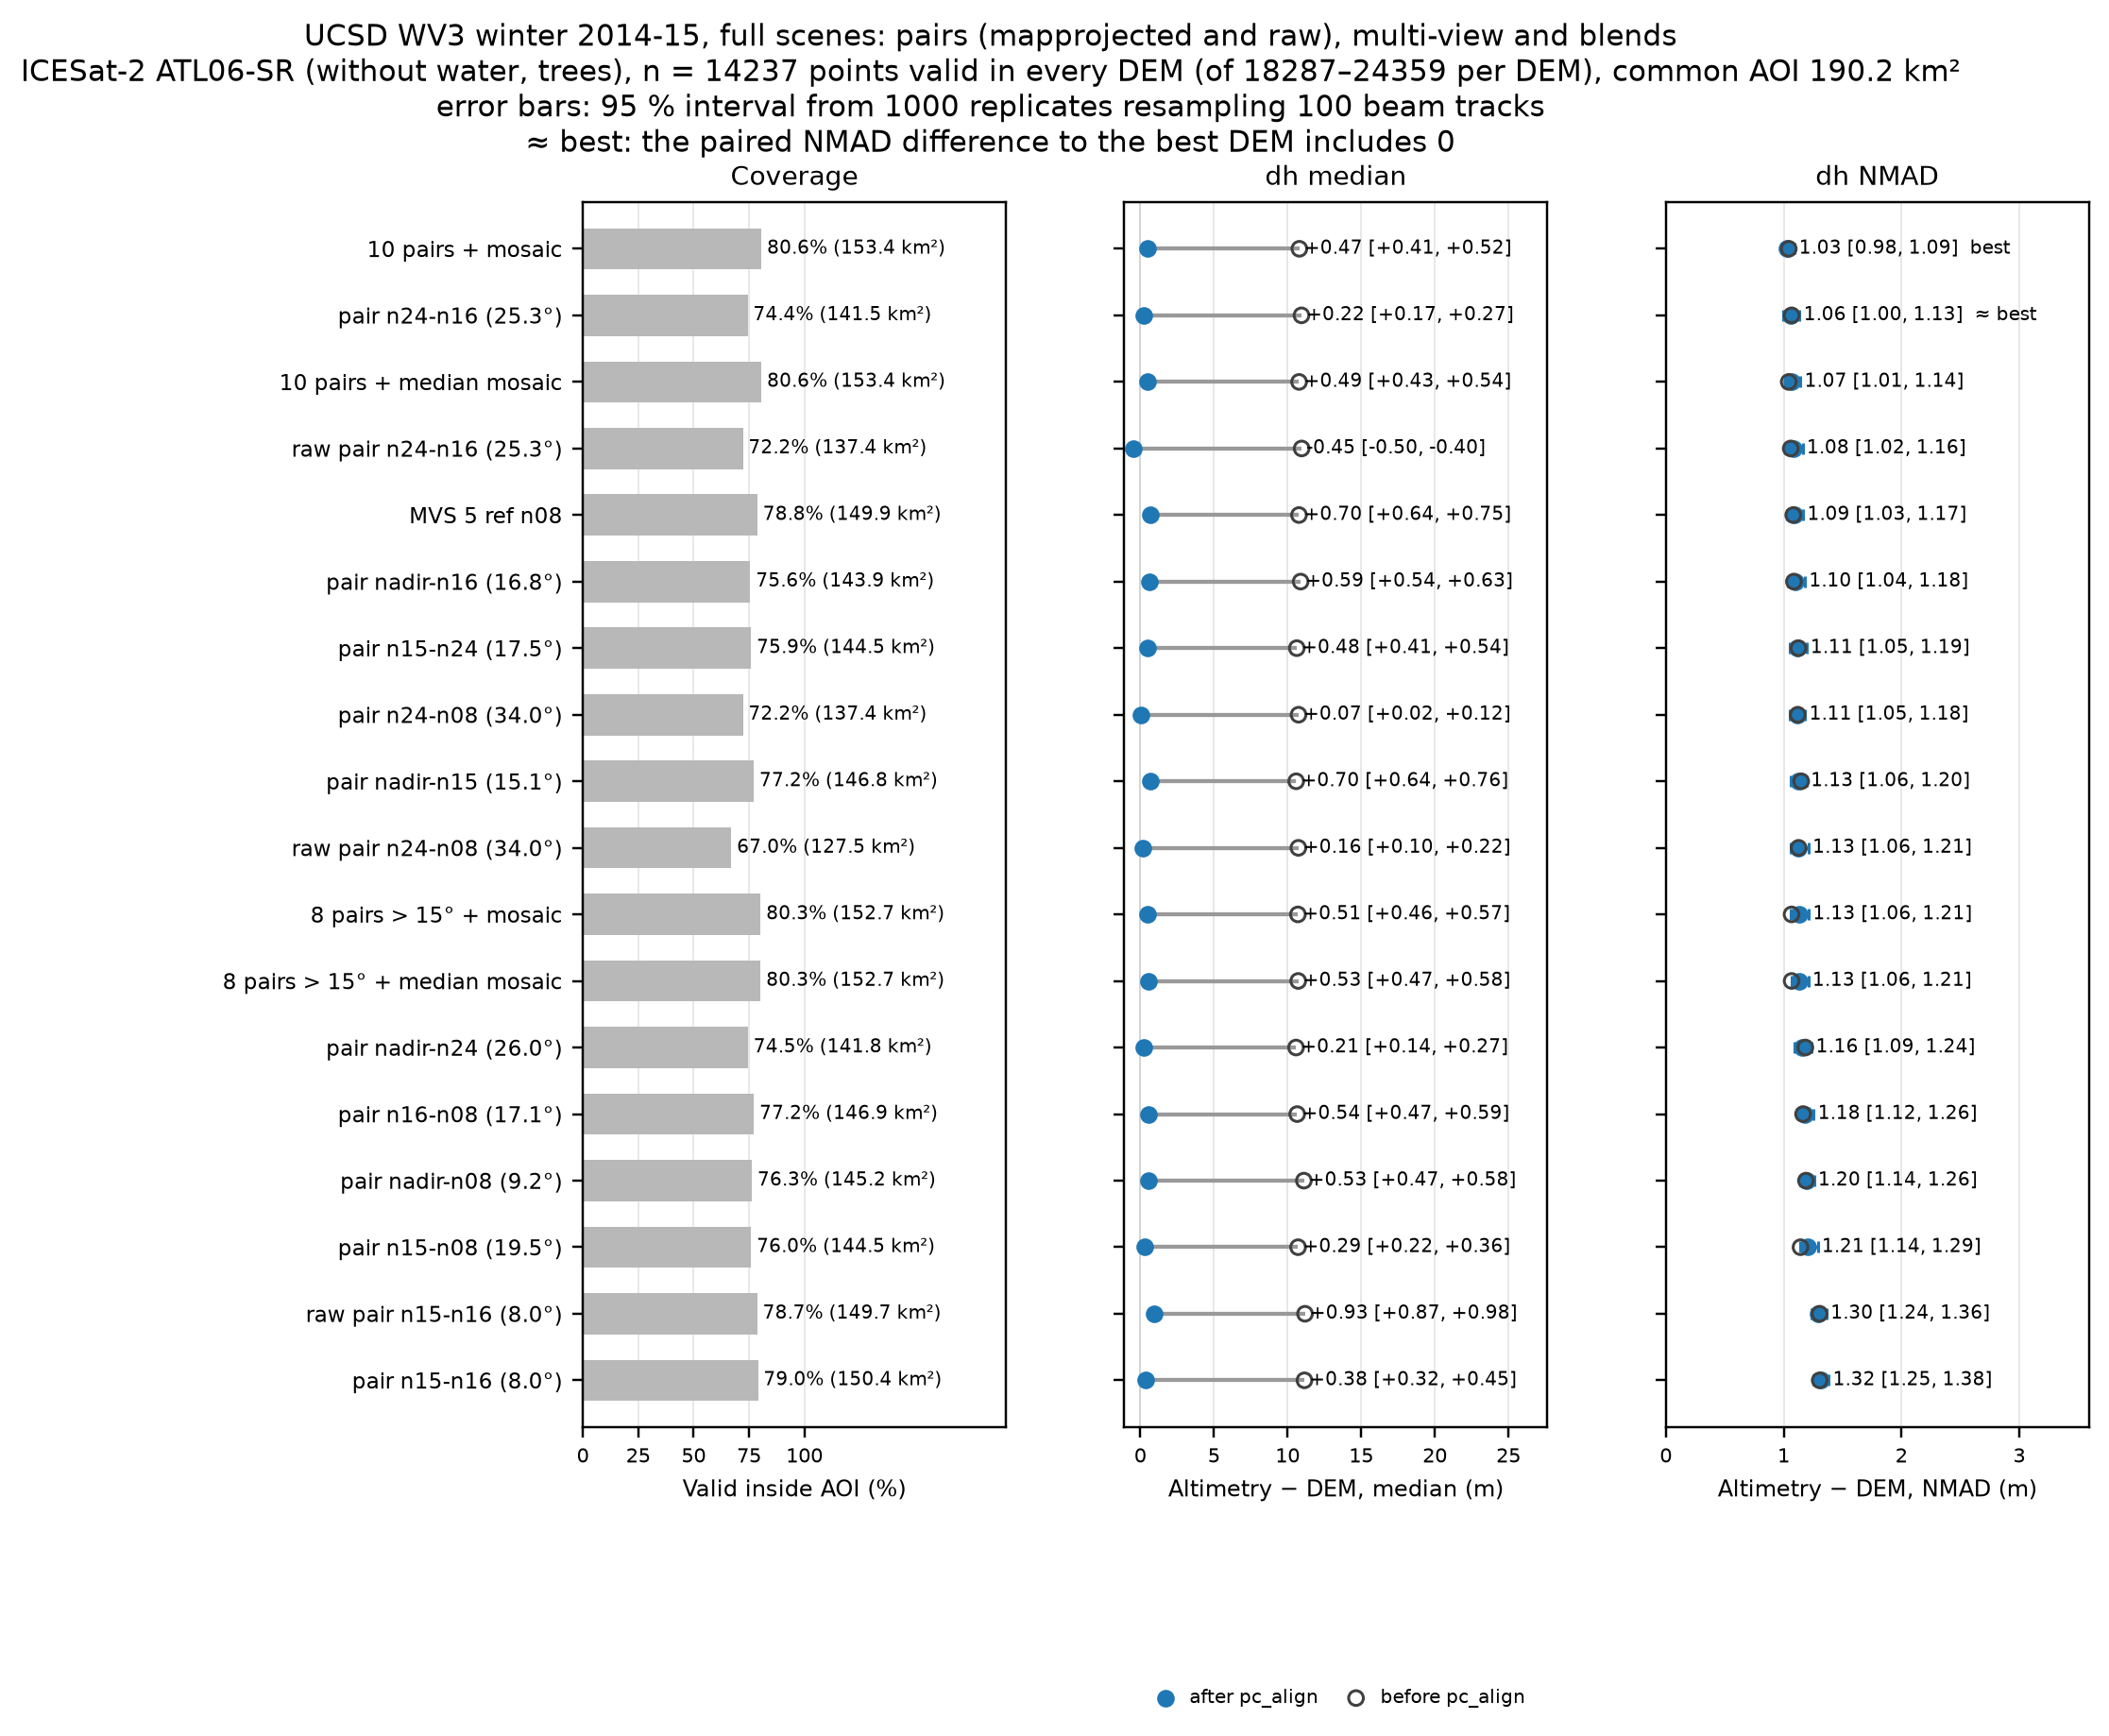

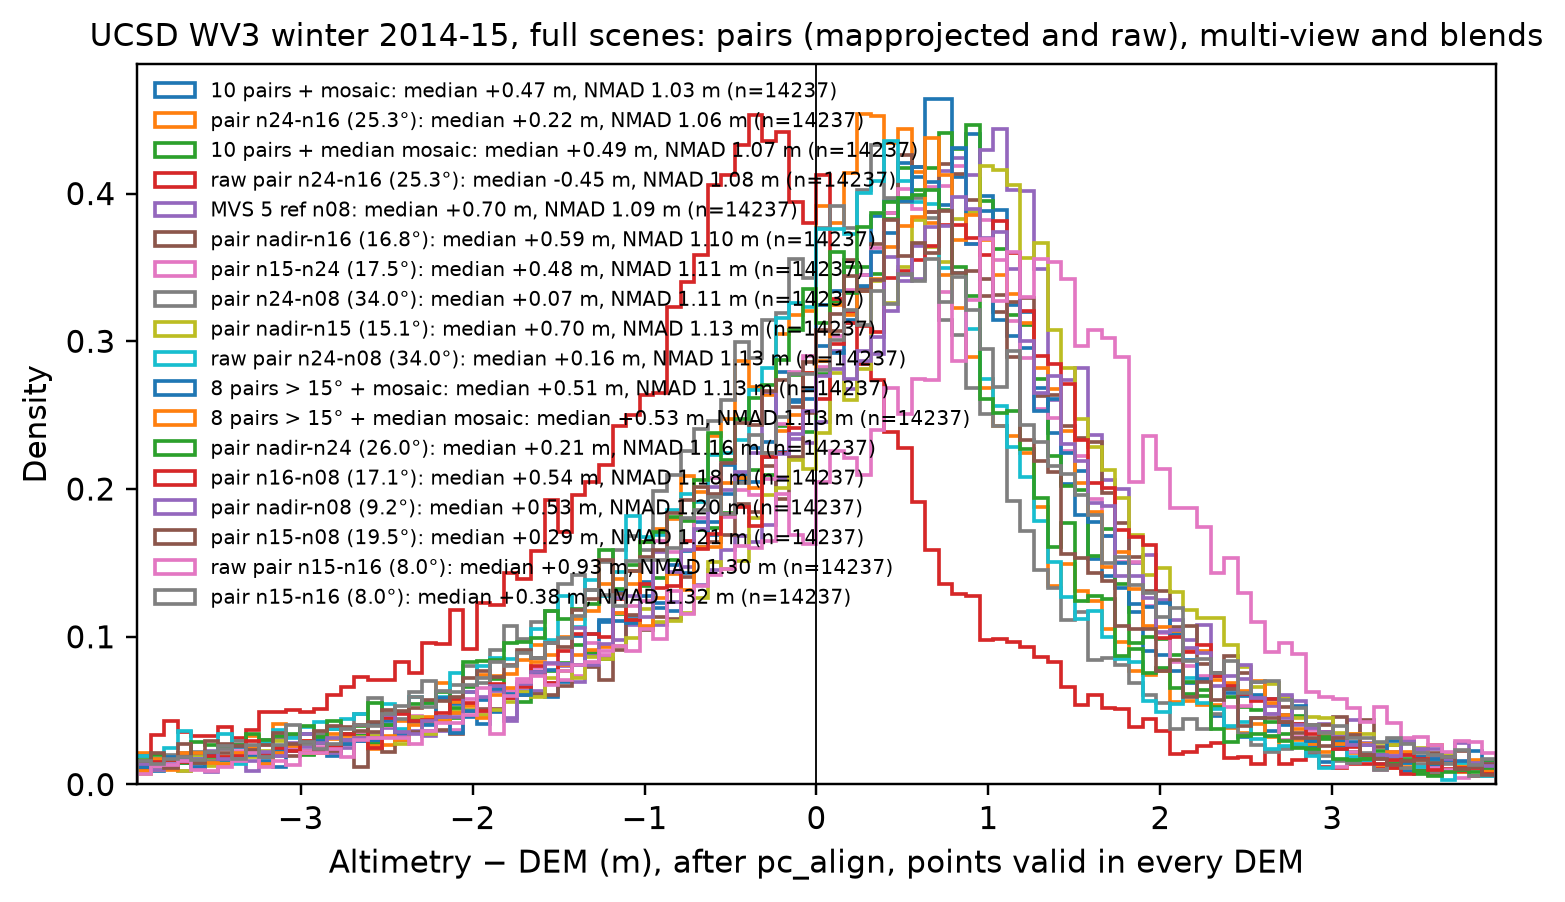

In [5]:
_ = bench.summary_plot()
_ = bench.histogram_plot()

---

## Single pairs: convergence angle, or which scenes?

The ten mapprojected pairs and three raw pairs on one axis. The cropped study's curve is drawn for comparison of shape, not level: it was scored on crop A with only water dropped. Pairs containing the 2014-11-09 nadir scene are circled, because in the crop three of the four worst pairs had it.

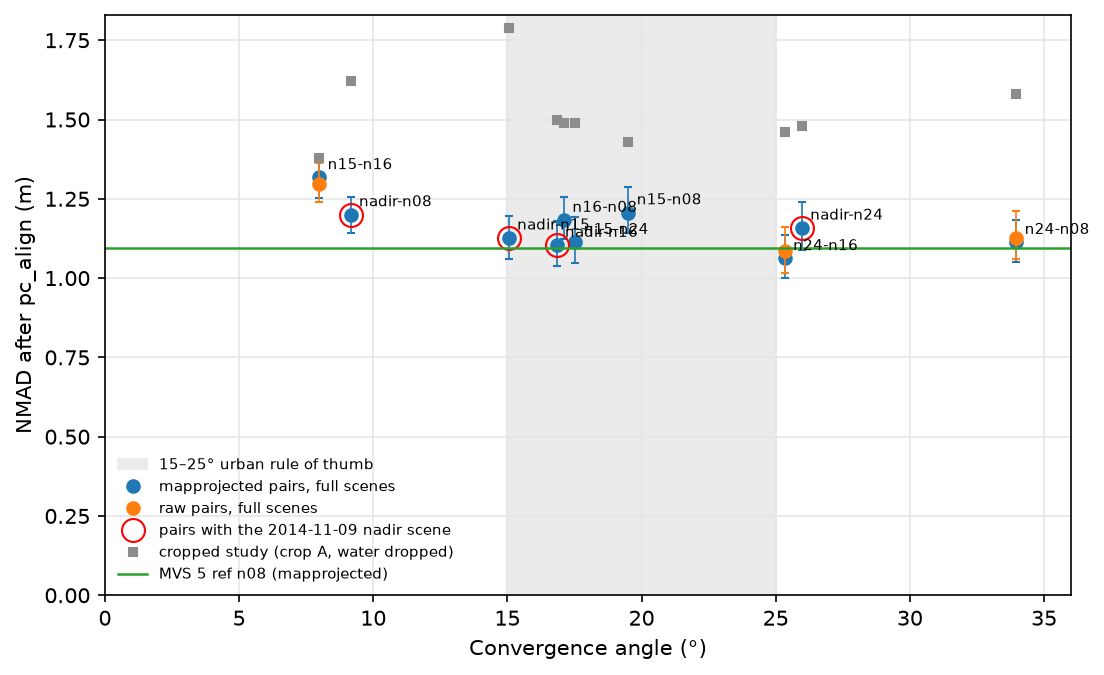

In [6]:
by = stats.set_index("label")
col = "dh_aligned_shared_nmad_m"
# The cropped study (worldview_spacenet_benchmark.ipynb, UCSD section): shared-point NMAD after pc_align, crop A
CROP = {
    "pairs": {"n15-n16": 1.38, "nadir-n08": 1.62, "nadir-n15": 1.79, "nadir-n16": 1.50, "n16-n08": 1.49,
              "n15-n24": 1.49, "n15-n08": 1.43, "n24-n16": 1.46, "nadir-n24": 1.48, "n24-n08": 1.58},
    "MVS 5 ref n08": 1.35, "MVS 5 ref nadir": 1.37, "MVS 5 ref n24": 1.38,
    "10 pairs + mosaic": 1.38, "10 pairs + median mosaic": 1.48,
    "8 pairs > 15° + mosaic": 1.44, "8 pairs > 15° + median mosaic": 1.55,
}


def pair_of(label):
    m = re.search(r"pair (\S+) \(", label)
    return m.group(1) if m else None


def pairs_table(prefix):
    p = by[by.index.str.startswith(prefix)].copy()
    p["pair"] = [pair_of(lbl) for lbl in p.index]
    p["convergence"] = p["pair"].map(conv_of)
    p["has nadir"] = p["pair"].str.contains("nadir")
    return p.sort_values("convergence")


map_pairs, raw_pairs = pairs_table("pair "), pairs_table("raw pair ")

fig, ax = plt.subplots(figsize=(7.5, 4.6), dpi=150)
ax.axvspan(15, 25, color="0.92", zorder=0, label="15–25° urban rule of thumb")
for p, color, name in ((map_pairs, "tab:blue", "mapprojected"), (raw_pairs, "tab:orange", "raw")):
    ax.plot(p["convergence"], p[col], "o", color=color, label=f"{name} pairs, full scenes")
    ax.errorbar(p["convergence"], p[col], fmt="none", ecolor=color, capsize=2, lw=0.8,
                yerr=[p[col] - p["nmad_ci_low_m"], p["nmad_ci_high_m"] - p[col]])
nad = map_pairs[map_pairs["has nadir"]]
ax.plot(nad["convergence"], nad[col], "o", mfc="none", mec="red", ms=11, label="pairs with the 2014-11-09 nadir scene")
for pr, v in map_pairs.set_index("pair")[col].items():
    ax.annotate(pr, (conv_of[pr], v), textcoords="offset points", xytext=(4, 4), fontsize=7)
cp = pd.Series(CROP["pairs"]).to_frame("nmad")
cp["convergence"] = cp.index.map(conv_of)
cp = cp.sort_values("convergence")
ax.plot(cp["convergence"], cp["nmad"], "s", color="0.55", ms=4, label="cropped study (crop A, water dropped)")
if "MVS 5 ref n08" in by.index:
    ax.axhline(by.loc["MVS 5 ref n08", col], ls="-", color="tab:green", lw=1.2, label="MVS 5 ref n08 (mapprojected)")
ax.set_xlabel("Convergence angle (°)")
ax.set_ylabel("NMAD after pc_align (m)")
ax.set_xlim(0, 36)
ax.set_ylim(bottom=0)
ax.grid(color="0.9")
ax.legend(fontsize=7, frameon=False, loc="lower left")
fig.tight_layout()

Convergence and scene membership are tangled in ten pairs from five scenes. The table below averages the mapprojected pair NMAD over the four pairs that contain each scene, and over the six that don't. A scene that degrades its pairs shows up as a higher mean "with" than "without". Every scene appears in pairs across a range of angles, but not the same range, so the mean convergence of its pairs is listed too.

In [7]:
rows = []
for s in SCENES.values():
    has = map_pairs["pair"].str.split("-").apply(lambda p: s in p)
    rows.append({"scene": s,
                 "mean NMAD, its 4 pairs": map_pairs.loc[has, col].mean(),
                 "mean NMAD, other 6 pairs": map_pairs.loc[~has, col].mean(),
                 "mean convergence, its pairs": map_pairs.loc[has, "convergence"].mean(),
                 "cropped study, its 4 pairs": np.mean([v for k, v in CROP["pairs"].items() if s in k.split("-")])})
scene_effect = pd.DataFrame(rows).set_index("scene")
scene_effect["with − without"] = scene_effect["mean NMAD, its 4 pairs"] - scene_effect["mean NMAD, other 6 pairs"]
scene_effect.sort_values("with − without", ascending=False).round(2)

,"mean NMAD, its 4 pairs","mean NMAD, other 6 pairs","mean convergence, its pairs","cropped study, its 4 pairs",with − without
scene,,,,,
n15,1.19,1.14,15.02,1.52,0.05
n08,1.18,1.15,19.94,1.53,0.03
n16,1.17,1.15,16.82,1.46,0.01
nadir,1.15,1.17,16.75,1.60,-0.02
n24,1.11,1.19,25.70,1.50,-0.08


---

## Flows: joint multi-view, pairwise + mosaic, best single pair

The same flows as the cropped study, all mapprojected, with the crop's NMAD for each DEM in the last column. In the crop, excluding pairs below 15° would have dropped its best pair (n15-n16, 8°).

In [8]:
best_map_pair = map_pairs[col].idxmin()
flows = [
    ("multi-view", "MVS 5 ref n08"),
    ("pairwise + mosaic", "10 pairs + mosaic"),
    ("pairwise + mosaic", "10 pairs + median mosaic"),
    ("pairwise + mosaic", "8 pairs > 15° + mosaic"),
    ("pairwise + mosaic", "8 pairs > 15° + median mosaic"),
    ("best single pair", best_map_pair),
]
cols = ["valid_pct", "n_shared", "dh_aligned_shared_nmad_m", "nmad_ci_low_m", "nmad_ci_high_m",
        "nmad_vs_best_ci_low_m", "nmad_vs_best_ci_high_m", "p_best"]
rows = []
for flow, lbl in flows:
    row = {"flow": flow, "DEM": lbl}
    row |= by.loc[lbl, cols].to_dict() if lbl in by.index else {"valid_pct": np.nan}
    row["cropped study NMAD"] = CROP["pairs"].get(pair_of(lbl)) if "pair " in lbl else CROP.get(lbl)
    rows.append(row)
pd.DataFrame(rows).set_index(["flow", "DEM"]).round(2)

valid_pct  n_shared  \
flow              DEM                                                  
multi-view        MVS 5 ref n08                      78.77   14237.0   
pairwise + mosaic 10 pairs + mosaic                  80.63   14237.0   
                  10 pairs + median mosaic           80.63   14237.0   
                  8 pairs > 15° + mosaic             80.26   14237.0   
                  8 pairs > 15° + median mosaic      80.26   14237.0   
best single pair  pair n24-n16 (25.3°)               74.39   14237.0   

                                                 dh_aligned_shared_nmad_m  \
flow              DEM                                                       
multi-view        MVS 5 ref n08                                      1.09   
pairwise + mosaic 10 pairs + mosaic                                  1.03   
                  10 pairs + median mosaic                           1.07   
                  8 pairs > 15° + mosaic                             1.13   
                  8 pairs > 15° + median mosaic                      1.13   
best single pair  pair n24-n16 (25.3°)                               1.06   

                                                 nmad_ci_low_m  \
flow              DEM                                            
multi-view        MVS 5 ref n08                           1.03   
pairwise + mosaic 10 pairs + mosaic                       0.98   
                  10 pairs + median mosaic                1.01   
                  8 pairs > 15° + mosaic                  1.06   
                  8 pairs > 15° + median mosaic           1.06   
best single pair  pair n24-n16 (25.3°)                    1.00   

                                                 nmad_ci_high_m  \
flow              DEM                                             
multi-view        MVS 5 ref n08                            1.17   
pairwise + mosaic 10 pairs + mosaic                        1.09   
                  10 pairs + median mosaic                 1.14   
                  8 pairs > 15° + mosaic                   1.21   
                  8 pairs > 15° + median mosaic            1.21   
best single pair  pair n24-n16 (25.3°)                     1.13   

                                                 nmad_vs_best_ci_low_m  \
flow              DEM                                                    
multi-view        MVS 5 ref n08                                   0.04   
pairwise + mosaic 10 pairs + mosaic                               0.00   
                  10 pairs + median mosaic                        0.02   
                  8 pairs > 15° + mosaic                          0.06   
                  8 pairs > 15° + median mosaic                   0.07   
best single pair  pair n24-n16 (25.3°)                           -0.00   

                                                 nmad_vs_best_ci_high_m  \
flow              DEM                                                     
multi-view        MVS 5 ref n08                                    0.10   
pairwise + mosaic 10 pairs + mosaic                                0.00   
                  10 pairs + median mosaic                         0.06   
                  8 pairs > 15° + mosaic                           0.14   
                  8 pairs > 15° + median mosaic                    0.13   
best single pair  pair n24-n16 (25.3°)                             0.07   

                                                 p_best  cropped study NMAD  
flow              DEM                                                        
multi-view        MVS 5 ref n08                    0.00                1.35  
pairwise + mosaic 10 pairs + mosaic                0.97                1.38  
                  10 pairs + median mosaic         0.00                1.48  
                  8 pairs > 15° + mosaic           0.00                1.44  
                  8 pairs > 15° + median mosaic    0.00                1.55  
best single pair  pair n24-n16 (25.3°)           

---

## Raw against mapprojected over steep terrain

Three pairs exist in both modes: same pairs, same cameras, same points. At Atlanta, which is flat, raw stereo won by 0.11–0.15 m on wide pairs and lost by 0.06–0.09 m at ~5°. The expectation here is that mapprojection helps more on slopes. The second table splits the residuals by slope, taken from the 30 m COP30 at each ICESat-2 point (independent of the DEMs), and by land cover.

In [9]:
rvm = []
for pr in raw_pairs["pair"]:
    m = map_pairs[map_pairs["pair"] == pr].iloc[0]
    r = raw_pairs[raw_pairs["pair"] == pr].iloc[0]
    rvm.append({"pair": pr, "convergence": conv_of[pr],
                "raw NMAD": r[col], "raw CI": f"[{r.nmad_ci_low_m:.2f}, {r.nmad_ci_high_m:.2f}]",
                "map NMAD": m[col], "map CI": f"[{m.nmad_ci_low_m:.2f}, {m.nmad_ci_high_m:.2f}]",
                "map − raw": m[col] - r[col],
                "raw valid %": r["valid_pct"], "map valid %": m["valid_pct"]})
pd.DataFrame(rvm).sort_values("convergence").set_index("pair").round(2)

,convergence,raw NMAD,raw CI,map NMAD,map CI,map − raw,raw valid %,map valid %
pair,,,,,,,,
n15-n16,7.99,1.30,"[1.24, 1.36]",1.32,"[1.25, 1.38]",0.02,78.71,79.03
n24-n16,25.34,1.08,"[1.02, 1.16]",1.06,"[1.00, 1.13]",-0.02,72.24,74.39
n24-n08,33.97,1.13,"[1.06, 1.21]",1.11,"[1.05, 1.18]",-0.01,67.04,72.24


In [10]:
import rasterio

from asp_plot.utils import nmad

with rasterio.open(f"{ref_dir}COP30_E_ucsd_32611.tif") as src:
    z = src.read(1).astype(float)
    z[z == src.nodata] = np.nan
    tr = src.transform
gy, gx = np.gradient(z, tr.e, tr.a)
cop_slope = np.degrees(np.arctan(np.hypot(gx, gy)))


def slope_at(p):
    p = p.to_crs(utm)
    rows_, cols_ = rasterio.transform.rowcol(tr, p.geometry.x.values, p.geometry.y.values)
    rows_, cols_ = np.asarray(rows_), np.asarray(cols_)
    ok = (rows_ >= 0) & (rows_ < z.shape[0]) & (cols_ >= 0) & (cols_ < z.shape[1])
    out = np.full(len(p), np.nan)
    out[ok] = cop_slope[rows_[ok], cols_[ok]]
    return out


def by_class(b, labels):
    rows = []
    for lbl in labels:
        p = b.altimetry[lbl].atl06sr_processing_levels_filtered["all"]
        p = p[p["benchmark_point_id"].isin(b.shared_ids)]
        dh = p["icesat_minus_aligned_dem"].values
        sl = slope_at(p)
        lc = p["esa_worldcover.value"].map(WC).values
        ok = np.isfinite(dh)
        rows.append({"DEM": lbl, "all": nmad(dh[ok]),
                     "slope ≤ 10°": nmad(dh[ok & (sl <= 10)]), "slope 10–20°": nmad(dh[ok & (sl > 10) & (sl <= 20)]),
                     "slope > 20°": nmad(dh[ok & (sl > 20)]),
                     "built": nmad(dh[ok & (lc == "built")]), "grass/shrub/bare": nmad(dh[ok & np.isin(lc, ["grass", "shrub", "bare"])])})
    return pd.DataFrame(rows).set_index("DEM")


both = [lbl for pr in raw_pairs["pair"] for lbl in by.index if pair_of(lbl) == pr] if len(raw_pairs) else []
p0 = bench.altimetry[both[0]].atl06sr_processing_levels_filtered["all"] if both else None
if p0 is not None:
    p0 = p0[p0["benchmark_point_id"].isin(bench.shared_ids)]
    s0 = slope_at(p0)
    print(f"shared points: slope ≤ 10° {np.sum(s0 <= 10)}, 10–20° {np.sum((s0 > 10) & (s0 <= 20))}, > 20° {np.sum(s0 > 20)}")
by_class(bench, sorted(both, key=lambda l: (pair_of(l), l))).round(2)

shared points: slope ≤ 10° 12549, 10–20° 1466, > 20° 222


,all,slope ≤ 10°,slope 10–20°,slope > 20°,built,grass/shrub/bare
DEM,,,,,,
pair n15-n16 (8.0°),1.32,1.27,1.63,1.72,1.40,1.13
raw pair n15-n16 (8.0°),1.30,1.26,1.54,1.75,1.32,1.24
pair n24-n08 (34.0°),1.11,1.08,1.33,1.53,1.21,0.89
raw pair n24-n08 (34.0°),1.13,1.09,1.49,1.53,1.20,0.95
pair n24-n16 (25.3°),1.06,1.02,1.36,1.92,1.15,0.85
raw pair n24-n16 (25.3°),1.08,1.04,1.46,1.69,1.17,0.88


---

## On crop A

Every full-scene DEM is clipped to crop A (UTM 11N 476000–479000 E, 3632000–3635000 N) and scored as the cropped study scored its DEMs: water dropped, trees kept, on the points valid in every DEM. There are two alignments:
- **Full-scene alignment:** each DEM's `pc_align` translation from the full-scene scoring above is applied, and the clip is scored without refitting. This compares the DEM itself on the crop's ground.
- **Refit on the clip:** `pc_align` is run again on the 9 km² clip, as the cropped study did. The smoke test showed this can fit a spurious horizontal shift here.

The two use different `directory` folders, so their `pc_align` caches stay separate.

In [11]:
from rasterio.windows import from_bounds


def clip(src_fn, dst_fn):
    os.makedirs(os.path.dirname(dst_fn), exist_ok=True)
    if os.path.exists(dst_fn):
        return dst_fn
    with rasterio.open(src_fn) as src:
        win = from_bounds(*CROP_A, transform=src.transform).round_offsets().round_lengths()
        prof = src.profile | {"width": win.width, "height": win.height, "transform": src.window_transform(win),
                              "compress": "lzw", "tiled": True, "blockxsize": 256, "blockysize": 256}
        with rasterio.open(dst_fn, "w", **prof) as dst:
            dst.write(src.read(window=win, boundless=True, fill_value=src.nodata))
    return dst_fn


safe = lambda s: re.sub(r"[^A-Za-z0-9]+", "_", s).strip("_")
fixed_dir, refit_dir = f"{directory}cropA_fullalign/", f"{directory}cropA_refit/"
fixed, refit = {}, {}
for lbl, fn in existing.items():
    translated = glob.glob(f"{bench.label_directory(lbl)}/*_pc_align_translated.tif")
    if translated:
        fixed[lbl] = clip(translated[0], f"{fixed_dir}{safe(lbl)}/run-DEM.tif")
    refit[lbl] = clip(fn, f"{refit_dir}{safe(lbl)}/run-DEM.tif")

bench_fixed = DEMBenchmark(directory=fixed_dir, dems=fixed, parquet=f"{directory}atl06sr_all.parquet",
                           reference=REF, filter_out="water",
                           title="Crop A: full-scene DEMs with their full-scene alignment (water dropped)")
stats_fixed = run_quietly(bench_fixed, pc_align=False).set_index("label")
bench_refit = DEMBenchmark(directory=refit_dir, dems=refit, parquet=f"{directory}atl06sr_all.parquet",
                           reference=REF, filter_out="water",
                           title="Crop A: full-scene DEMs, pc_align refitted on the clip (water dropped)")
stats_refit = run_quietly(bench_refit).set_index("label")

crop_of = lambda lbl: CROP["pairs"].get(pair_of(lbl)) if "pair " in lbl else CROP.get(lbl)
cmp_a = pd.DataFrame({
    "full-scene alignment": stats_fixed["dh_shared_nmad_m"],
    "refit on clip": stats_refit[col],
    "cropped study": [crop_of(l) for l in stats_fixed.index],
    "valid %": stats_fixed["valid_pct"],
})
cmp_a["full-scene alignment − cropped"] = cmp_a["full-scene alignment"] - cmp_a["cropped study"]
cmp_a.sort_values("full-scene alignment").round(2)

=== [1/18] pair n15-n16 (8.0°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/cropA_fullalign/pair_n15_n16_8_0/run-DEM.tif
  645 altimetry points: median +1.12 m, NMAD 1.53 m
=== [2/18] pair nadir-n08 (9.2°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/cropA_fullalign/pair_nadir_n08_9_2/run-DEM.tif
  648 altimetry points: median +0.80 m, NMAD 1.54 m
=== [3/18] pair nadir-n15 (15.1°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/cropA_fullalign/pair_nadir_n15_15_1/run-DEM.tif
  646 altimetry points: median +0.57 m, NMAD 1.57 m
=== [4/18] pair nadir-n16 (16.8°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/cropA_fullalign/pair_nadir_n16_16_8/run-DEM.tif
  646 altimetry points: median +0.58 m, NMAD 1.65 m
=== [5/18] pair n16-n08 (17.1°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/cropA_fullalign/pair_n16_n08_17_1/run-DEM.tif
  645 altimetry points: median +0.45 m, NMAD 1.55 m
=== [6/18] pair n15-n24 (17.5°): /nobackup/bpurint1/data/ucsd/

=== [1/18] pair n15-n16 (8.0°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/cropA_refit/pair_n15_n16_8_0/run-DEM.tif
  647 altimetry points: median +11.67 m, NMAD 1.55 m
  after pc_align (|t| = 11.72 m): median -0.06 m, NMAD 1.55 m
=== [2/18] pair nadir-n08 (9.2°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/cropA_refit/pair_nadir_n08_9_2/run-DEM.tif
  648 altimetry points: median +11.69 m, NMAD 1.58 m
  after pc_align (|t| = 11.38 m): median +0.19 m, NMAD 1.68 m
=== [3/18] pair nadir-n15 (15.1°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/cropA_refit/pair_nadir_n15_15_1/run-DEM.tif
  645 altimetry points: median +10.72 m, NMAD 1.67 m
  after pc_align (|t| = 10.57 m): median +0.55 m, NMAD 1.92 m
=== [4/18] pair nadir-n16 (16.8°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/cropA_refit/pair_nadir_n16_16_8/run-DEM.tif
  639 altimetry points: median +11.42 m, NMAD 1.49 m
  after pc_align (|t| = 11.27 m): median +0.11 m, NMAD 1.52 m
=== [5/18] p

,full-scene alignment,refit on clip,cropped study,valid %,full-scene alignment − cropped
label,,,,,
10 pairs + mosaic,1.26,1.35,1.38,99.99,-0.12
raw pair n15-n16 (8.0°),1.33,1.73,1.38,99.06,-0.05
pair n24-n08 (34.0°),1.33,1.37,1.58,95.41,-0.25
raw pair n24-n16 (25.3°),1.37,1.32,1.46,90.93,-0.09
pair n15-n24 (17.5°),1.38,1.49,1.49,98.09,-0.11
pair nadir-n15 (15.1°),1.40,1.68,1.79,98.71,-0.39
10 pairs + median mosaic,1.43,1.31,1.48,99.99,-0.05
pair n24-n16 (25.3°),1.47,1.27,1.46,95.96,0.01
pair n16-n08 (17.1°),1.47,1.49,1.49,97.83,-0.02


---

## Trees and all land

The cropped study kept tree points, and 45 % of crop A is tree cover. The full-scene ranking above drops them. The same DEMs scored on all land points (water dropped only) show how much the choice moves the numbers and the ranking.

In [12]:
land_dir = f"{directory}land/"
os.makedirs(land_dir, exist_ok=True)
bench_land = DEMBenchmark(directory=land_dir, dems=existing, parquet=f"{directory}atl06sr_all.parquet",
                          reference=REF, filter_out="water",
                          title="Full scenes, all land points (water dropped only)")
stats_land = run_quietly(bench_land).set_index("label")
pd.DataFrame({"stable terrain": by[col], "all land": stats_land[col],
              "n_shared stable": by["n_shared"], "n_shared land": stats_land["n_shared"]}).sort_values("stable terrain").round(2)

=== [1/18] pair n15-n16 (8.0°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/map/stereo_pair_n15_n16/run-DEM.tif
  27283 altimetry points: median +11.08 m, NMAD 1.57 m
  after pc_align (|t| = 10.77 m): median +0.35 m, NMAD 1.57 m
=== [2/18] pair nadir-n08 (9.2°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/map/stereo_pair_nadir_n08/run-DEM.tif
  23574 altimetry points: median +11.04 m, NMAD 1.48 m
  after pc_align (|t| = 11.56 m): median +0.31 m, NMAD 1.49 m
=== [3/18] pair nadir-n15 (15.1°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/map/stereo_pair_nadir_n15/run-DEM.tif
  23971 altimetry points: median +10.39 m, NMAD 1.50 m
  after pc_align (|t| = 10.46 m): median +0.67 m, NMAD 1.44 m
=== [4/18] pair nadir-n16 (16.8°): /nobackup/bpurint1/data/ucsd/WV3/core3d/full_benchmark/map/stereo_pair_nadir_n16/run-DEM.tif
  23441 altimetry points: median +10.82 m, NMAD 1.34 m
  after pc_align (|t| = 11.06 m): median +0.62 m, NMAD 1.31 m
=== [5/18] pair n16-n08 (1

,stable terrain,all land,n_shared stable,n_shared land
label,,,,
10 pairs + mosaic,1.03,1.16,14237,17405
pair n24-n16 (25.3°),1.06,1.18,14237,17405
10 pairs + median mosaic,1.07,1.16,14237,17405
raw pair n24-n16 (25.3°),1.08,1.22,14237,17405
MVS 5 ref n08,1.09,1.22,14237,17405
pair nadir-n16 (16.8°),1.10,1.19,14237,17405
pair n15-n24 (17.5°),1.11,1.25,14237,17405
pair n24-n08 (34.0°),1.11,1.24,14237,17405
pair nadir-n15 (15.1°),1.13,1.23,14237,17405


Most stable-terrain points are on gentle ground: the steep canyon walls are mostly wooded, so dropping trees also drops most steep points. The raw-against-mapprojected split by slope is repeated on all land points, which keep them.

In [13]:
if both:
    p0 = bench_land.altimetry[both[0]].atl06sr_processing_levels_filtered["all"]
    s0 = slope_at(p0[p0["benchmark_point_id"].isin(bench_land.shared_ids)])
    print(f"shared land points: slope ≤ 10° {np.sum(s0 <= 10)}, 10–20° {np.sum((s0 > 10) & (s0 <= 20))}, > 20° {np.sum(s0 > 20)}")
by_class(bench_land, sorted(both, key=lambda l: (pair_of(l), l))).round(2)

shared land points: slope ≤ 10° 14496, 10–20° 2464, > 20° 445


,all,slope ≤ 10°,slope 10–20°,slope > 20°,built,grass/shrub/bare
DEM,,,,,,
pair n15-n16 (8.0°),1.42,1.36,1.77,1.69,1.40,1.12
raw pair n15-n16 (8.0°),1.44,1.36,1.72,1.75,1.33,1.29
pair n24-n08 (34.0°),1.24,1.17,1.64,1.92,1.22,0.89
raw pair n24-n08 (34.0°),1.29,1.20,1.78,1.73,1.21,0.96
pair n24-n16 (25.3°),1.18,1.11,1.58,1.98,1.16,0.85
raw pair n24-n16 (25.3°),1.22,1.14,1.69,1.92,1.14,0.89


---

## Takeaways

What the two full-scene sites say about the cropped study's practical rules:

| rule | Atlanta full strips (same pass, flat) | UCSD full scenes (multi-date, steep) |
|---|---|---|
| Convergence angle sets pair accuracy | holds; flat past ~20° | holds up to ~15°; beyond that the date pairing matters as much |
| Pairwise flow: drop pairs below ~15°, or use `--median` | holds: 0.86 / 0.87 m against 1.08 m for the plain average | reverses: the plain average of all ten is best (1.03 m); dropping costs 0.10 m |
| Multi-view: the reference scene is the main choice | no measurable effect | not tested (one reference); the joint run trails the average by 0.06 m |
| Raw or mapprojected | raw wins by 0.11–0.15 m on wide pairs | a tie; mapprojected covers more and helps a little on slopes |

**A combined rule from both sites.** Use a pairwise flow, and choose the blend by the stack:
- for a same-pass stack, drop the narrow pairs or blend with `--median`;
- for a multi-date stack, average all the pairs.

The joint multi-view run never beat the best blend at either site.

**Follow-ups:**
- Mapproject onto a better reference, e.g. the 10-pair blend itself or 3DEP lidar, to see whether the slope gains grow.
- A denser reference on steep ground (lidar or a DEM-to-DEM comparison): ICESat-2 barely samples the canyon walls once trees are dropped.
- Run the multi-date blends by date separation, to test whether averaging gains come from independent dates.
- `jitter_solve`, as for Atlanta.